# Data cleaning and Feature Engineering

## Preperation

Imports

In [174]:
# 1. Import the necessary modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
import matplotlib.dates as mdates
import statsmodels.api as sm

# 2. Create a DataFrame using the provided data
# df = pd.read_parquet("OC_sales_DE_pseudonymized.parquet")
df = pd.read_parquet("cleaned_data.parquet")
print(df.head())
print(df.info())

     Industry    Product_Family     CHF  fill_rate order_date  Customer_id  \
0  Automotive  TF Forming Tools   25.61   0.034615 2023-01-02            1   
1  Automotive  TF Forming Tools   51.84   0.014286 2023-01-02            1   
2  Automotive  TF Forming Tools   55.65   0.090476 2023-01-02            1   
3  Automotive  TF Forming Tools   33.53   0.050000 2023-01-02            1   
4  Automotive  TF Cutting Tools  103.35   0.050000 2023-01-02            1   

   coating_id weekday  
0           1  Monday  
1           1  Monday  
2           2  Monday  
3           2  Monday  
4           3  Monday  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744813 entries, 0 to 744812
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Industry        744813 non-null  category      
 1   Product_Family  744813 non-null  category      
 2   CHF             744813 non-null  float64       
 3   fill_ra

## Data Inspection

Test if there are any negative values

In [175]:
for col in ["CHF", "fill_rate", "Customer_id", "coating_id"]:
    if (df[col]<=0).any():
        print(f"Column {col} contains non-positive values: {df[col]<0}")

Column CHF contains non-positive values: 0         False
1         False
2         False
3         False
4         False
          ...  
744808    False
744809    False
744810    False
744811    False
744812    False
Name: CHF, Length: 744813, dtype: bool
Column fill_rate contains non-positive values: 0         False
1         False
2         False
3         False
4         False
          ...  
744808    False
744809    False
744810    False
744811    False
744812    False
Name: fill_rate, Length: 744813, dtype: bool


Data range für variables

In [176]:
# For each column in df, print min/max for numeric, unique values for categorical/object
for column in df.columns:
    print(f"\nColumn: {column}")
    if pd.api.types.is_numeric_dtype(df[column]):
        print(f"  Min: {df[column].min()}")
        print(f"  Max: {df[column].max()}")
    elif pd.api.types.is_datetime64_any_dtype(df[column]):
        print(f"  Min: {df[column].min()}")
        print(f"  Max: {df[column].max()}")
    else:
        unique_vals = df[column].unique()
        print(f"  Unique values ({len(unique_vals)}): {unique_vals}")


Column: Industry
  Unique values (7): ['Automotive', 'General Industry', 'Tooling', 'Medical', 'Aerospace', 'Not assigned', 'Power Generation']
Categories (7, object): ['Aerospace', 'Automotive', 'General Industry', 'Medical', 'Not assigned', 'Power Generation', 'Tooling']

Column: Product_Family
  Unique values (3): ['TF Forming Tools', 'TF Cutting Tools', 'TF Precision Compone']
Categories (3, object): ['TF Cutting Tools', 'TF Forming Tools', 'TF Precision Compone']

Column: CHF
  Min: 0.0
  Max: 66028.83

Column: fill_rate
  Min: 0.0
  Max: 2120.8333333333335

Column: order_date
  Min: 2023-01-02 00:00:00
  Max: 2025-04-01 00:00:00

Column: Customer_id
  Min: 1
  Max: 376

Column: coating_id
  Min: 1
  Max: 121

Column: weekday
  Unique values (5): ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
Categories (5, object): ['Friday', 'Monday', 'Thursday', 'Tuesday', 'Wednesday']


Rows per Coating id

In [177]:
# Print the number of rows per coating_id
print(df['coating_id'].value_counts().sort_index())
print(f"Total unique coating IDs: {df['coating_id'].nunique()}")

coating_id
1       45505
2       18120
3      216686
4        5888
5       11038
6        8216
7       44650
8       32009
9       65523
10       5573
12      19313
13       3610
15      31016
16      35296
20       8112
21       6415
22      34100
23      17315
24       3316
25       4168
27      12895
28       3394
29      14213
30      11281
33       4047
40       8543
46       7288
52       8656
54       3219
59       6514
68       8411
69       3726
80      19972
110      7156
117      3741
121      5888
Name: count, dtype: int64
Total unique coating IDs: 36


Test if the coating IDs are only used by the same product family and industry

In [178]:
# Check uniqueness of Industry and Product_Family per coating_id
industry_unique = df.groupby('coating_id')['Industry'].nunique()
product_family_unique = df.groupby('coating_id')['Product_Family'].nunique()

# coating_ids with more than one Industry or Product_Family
multi_industry = industry_unique[industry_unique > 1]
multi_product_family = product_family_unique[product_family_unique > 1]

print("Coating IDs with multiple Industries:", multi_industry.index.tolist())
print("Coating IDs with multiple Product Families:", multi_product_family.index.tolist())

Coating IDs with multiple Industries: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 15, 16, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 33, 40, 46, 52, 54, 59, 68, 69, 80, 110, 117, 121]
Coating IDs with multiple Product Families: [1, 2, 3, 4, 5, 6, 7, 8, 9, 12, 15, 16, 20, 21, 22, 23, 24, 25, 27, 29, 30, 33, 40, 52, 54, 59, 68, 110, 117, 121]


Test if the same customer orders the same coating ID multiple times on the same day

In [179]:
# Check for duplicate (order_date, coating_id, Customer_id) combinations
duplicates = df.duplicated(subset=['order_date', 'coating_id', 'Customer_id'], keep=False)
num_duplicates = df[duplicates].shape[0]

if num_duplicates > 0:
    print(f"Yes, there are {num_duplicates} rows where the same Customer_id ordered the same coating_id on the same day multiple times.")
    display(df[duplicates].sort_values(['order_date', 'coating_id', 'Customer_id']))
else:
    print("No, each Customer_id orders each coating_id at most once per day.")

Yes, there are 699696 rows where the same Customer_id ordered the same coating_id on the same day multiple times.


,Industry,Product_Family,CHF,fill_rate,order_date,Customer_id,coating_id,weekday
0,Automotive,TF Forming Tools,25.61,0.034615,2023-01-02,1,1,Monday
1,Automotive,TF Forming Tools,51.84,0.014286,2023-01-02,1,1,Monday
61,General Industry,TF Forming Tools,205.80,0.003333,2023-01-02,5,1,Monday
62,General Industry,TF Forming Tools,609.80,0.050000,2023-01-02,5,1,Monday
63,General Industry,TF Forming Tools,464.21,0.041667,2023-01-02,5,1,Monday
...,...,...,...,...,...,...,...,...
744808,Not assigned,TF Cutting Tools,1608.87,0.087963,2025-04-01,41,21,Tuesday
744809,Not assigned,TF Cutting Tools,50.80,0.002778,2025-04-01,41,21,Tuesday
744810,Not assigned,TF Cutting Tools,547.74,0.037500,2025-04-01,41,21,Tuesday
744811,Not assigned,TF Cutting Tools,1880.92,0.074242,2025-04-01,41,21,Tuesday


## Aggregate the data set

Aggregate the data set.  
We added zeros for all weekdays where no orders have been placed for the coating IDs

In [185]:
def get_top_n(s, n=1):
    vcounts = s.value_counts()
    if len(vcounts) >= n:
        return vcounts.index[n-1]
    else:
        return np.nan

def mean_chf_per_customer(x):
    customers = df.loc[x.index, 'Customer_id']
    return x.sum() / customers.nunique()

def median_chf_per_customer(x):
    customers = df.loc[x.index, 'Customer_id']
    customer_sums = x.groupby(customers).sum()
    return customer_sums.median()

# 1. Aggregate engineered features from original df
agg = df.groupby(['order_date', 'coating_id']).agg(
    # target: fill rate
    target_fill_rate=('fill_rate', 'sum'),
    
    # feature 1: CHF (Revenue features)
    total_chf=('CHF', 'sum'),
    mean_chf=('CHF', 'mean'),
    median_chf=('CHF', 'median'),
    min_chf=('CHF', 'min'),
    max_chf=('CHF', 'max'),
    mean_chf_per_customer=('CHF', mean_chf_per_customer),
    median_chf_per_customer=('CHF', median_chf_per_customer),
    
    # feature 2: number of orders
    num_orders=('fill_rate', 'count'),
    max_orders_over_all_customer=('Customer_id', lambda x: x.value_counts().max()),
    min_orders_over_all_customer=('Customer_id', lambda x: x.value_counts().min()),
    mean_orders_over_all_customers=('Customer_id', lambda x: x.value_counts().mean()),
    median_orders_over_all_customer=('Customer_id', lambda x: x.value_counts().median()),
    num_big_customers=('Customer_id', lambda x: (x.value_counts() > 1).sum()),
    
    # feature 3: number of unique customers    
    num_customers=('Customer_id', 'nunique'),
    # biggest_customer_id=('Customer_id', lambda x: x.value_counts().idxmax()),
    # biggest_customer_share=('Customer_id', lambda x: x.value_counts().max() / x.size),
    # biggest_customer_orders=('Customer_id', lambda x: x.value_counts().max()),
    # biggest_customer_volume=('Customer_id', lambda x: x.sum() / (x.nunique() + 1e-5)),
    # biggest_customer_mean_chf=('Customer_id', lambda x: x.mean() / (x.nunique() + 1e-5)),
    # biggest_customer_median_chf=('Customer_id', lambda x: x.median() / (x.nunique() + 1e-5)),
    # biggest_customer_min_chf=('Customer_id', lambda x: x.min() / (x.nunique() + 1e-5)),
    # biggest_customer_max_chf=('Customer_id', lambda x: x.max() / (
    # - sales per group this year so far - identify demand increase
    # - days since last order 
    # - customer order count (compare it to last year/month)
    # Same thing for the second biggest, smallest? 
    
    # feature 4: number of unique industries
    num_industries=('Industry', 'nunique'),
    main_industry=('Industry', lambda x: x.value_counts().idxmax()),
    second_biggest_industry=('Industry', lambda x: get_top_n(x, 2)),
    third_biggest_industry=('Industry', lambda x: get_top_n(x, 3)),
    
    # feature 5: number of unique product families
    num_product_families=('Product_Family', 'nunique'),
    main_product_family=('Product_Family', lambda x: x.value_counts().idxmax()),
    second_biggest_product_family=('Product_Family', lambda x: get_top_n(x, 2)),
    third_biggest_product_family=('Product_Family', lambda x: get_top_n(x, 3)),
    
    # feature 6: calendar features
    month      =('order_date', lambda x: x.iloc[0].month),
    day        =('order_date', lambda x: x.iloc[0].day),
    year       =('order_date', lambda x: x.iloc[0].year),
    weekday    =('order_date', lambda x: x.iloc[0].weekday()),
    week_of_year=('order_date', lambda x: x.iloc[0].isocalendar().week),
    quarter    =('order_date', lambda x: x.iloc[0].quarter),
).reset_index()

# Use NRW holidays for holiday features
nrw_holidays = holidays.country_holidays('DE', subdiv='NW')
agg['is_holiday'] = agg['order_date'].isin(nrw_holidays)
agg['day_before_holiday'] = agg['order_date'].shift(-1).isin(nrw_holidays)
agg['day_after_holiday'] = agg['order_date'].shift(1).isin(nrw_holidays)

# Week-based holiday flags
agg['holiday_week'] = agg['order_date'].apply(lambda x: any([(x + pd.Timedelta(days=i)) in nrw_holidays for i in range(-x.weekday(), 7-x.weekday())]))
# agg['week_before_holiday'] = agg['order_date'].apply(lambda x: any([(x + pd.Timedelta(days=i)) in nrw_holidays for i in range(1,8)]))
# agg['week_after_holiday'] = agg['order_date'].apply(lambda x: any([(x - pd.Timedelta(days=i)) in nrw_holidays for i in range(1,8)]))
# currently considers the next 8 days. Goal: 
# 1. Assign week and year numbers
agg['year'] = agg['order_date'].dt.isocalendar().year
agg['week'] = agg['order_date'].dt.isocalendar().week

# 2. Build a week-level DataFrame
week_df = agg[['year', 'week']].drop_duplicates().sort_values(['year', 'week']).reset_index(drop=True)

# 3. For each week, does it contain a holiday?
# Find all dates in the dataset, map to week/year
agg['is_holiday'] = agg['order_date'].isin(nrw_holidays)
week_holiday = agg.groupby(['year', 'week'])['is_holiday'].any().reset_index()
week_holiday = week_holiday.rename(columns={'is_holiday': 'holiday_week'})

# 4. Merge to week_df so each week knows if it is a holiday week
week_df = week_df.merge(week_holiday, on=['year', 'week'], how='left').fillna(False)

# 5. Create flags for week before/after holiday week
week_df['week_before_holiday'] = week_df['holiday_week'].shift(-1, fill_value=False)
week_df['week_after_holiday'] = week_df['holiday_week'].shift(1, fill_value=False)

# 6. Merge these flags back to your daily data
agg = agg.merge(week_df[['year', 'week', 'holiday_week', 'week_before_holiday', 'week_after_holiday']],
                on=['year', 'week'], how='left')


# Bridgeday flag: if today is a Monday or Friday and is between a weekend and a holiday
agg['bridgeday_flag'] = (
    ((agg['weekday'] == 0) & agg['day_after_holiday']) |  # Monday after a holiday weekend
    ((agg['weekday'] == 4) & agg['day_before_holiday'])   # Friday before a holiday weekend
)

# Month progression (day number divided by number of days in month)
agg['month_progression'] = agg['order_date'].dt.day / agg['order_date'].dt.days_in_month

# Year progression (fix: use np.where for leap years)
days_in_year = np.where(agg['order_date'].dt.is_leap_year, 366, 365)
agg['year_progression'] = agg['order_date'].dt.dayofyear / days_in_year

# Quarter progression
quarter_period = agg['order_date'].dt.to_period('Q')
quarter_starts = quarter_period.apply(lambda p: p.start_time).dt.dayofyear
quarter_ends = quarter_period.apply(lambda p: p.end_time).dt.dayofyear
days_in_quarter = quarter_ends - quarter_starts + 1
agg['quarter_progression'] = ((agg['order_date'].dt.dayofyear - quarter_starts) / days_in_quarter).clip(0, 1)




    # month_progression
    # year_progression
    # quarter progression
    # week_progression - week of year
    # holiday
    # day_before_holiday
    # day_after_holiday
    # holiday_week flag
    # week after holiday flag
    # week before holiday flag
    # bridgeday flag
    
# Sort for rolling calculations
agg = agg.sort_values(['coating_id', 'order_date']).reset_index(drop=True)

# Rolling and lag features (example: 7-day rolling mean/sum for fill_rate and CHF)
for window in [3, 7, 30]:
    agg[f'fill_rate_roll_mean_{window}'] = agg.groupby('coating_id')['target_fill_rate'].transform(lambda x: x.rolling(window, min_periods=1).mean())
    agg[f'fill_rate_roll_sum_{window}'] = agg.groupby('coating_id')['target_fill_rate'].transform(lambda x: x.rolling(window, min_periods=1).sum())
    agg[f'chf_roll_mean_{window}'] = agg.groupby('coating_id')['total_chf'].transform(lambda x: x.rolling(window, min_periods=1).mean())

# Lag features: previous day's fill_rate/CHF
agg['lag1_fill_rate'] = agg.groupby('coating_id')['target_fill_rate'].shift(1)
agg['lag7_fill_rate'] = agg.groupby('coating_id')['target_fill_rate'].shift(7)
agg['lag1_chf'] = agg.groupby('coating_id')['total_chf'].shift(1)
agg['lag7_chf'] = agg.groupby('coating_id')['total_chf'].shift(7)

all_coating_ids = agg['coating_id'].unique()
min_date = agg['order_date'].min()
max_date = agg['order_date'].max()
all_dates = pd.date_range(min_date, max_date, freq='D')

# All combinations (Mon-Fri only)
full_index = pd.MultiIndex.from_product(
    [all_dates, all_coating_ids],
    names=['order_date', 'coating_id']
)
full_df = pd.DataFrame(index=full_index).reset_index()
full_df['weekday'] = full_df['order_date'].dt.weekday
full_df = full_df[full_df['weekday'] < 5].drop(columns='weekday')  # Keep only Mon-Fri

# Merge and fill NA
agg_full = pd.merge(full_df, agg, on=['order_date', 'coating_id'], how='left')
for col in agg.columns:
    if col not in ['order_date', 'coating_id']:
        if pd.api.types.is_numeric_dtype(agg_full[col]):
            agg_full[col] = agg_full[col].fillna(0)
        elif pd.api.types.is_categorical_dtype(agg_full[col]):
            if 'None' not in agg_full[col].cat.categories:
                agg_full[col] = agg_full[col].cat.add_categories(['None'])
            agg_full[col] = agg_full[col].fillna('None')
        else:
            agg_full[col] = agg_full[col].fillna('None')


agg_full['weekday_sin'] = np.sin(2 * np.pi * agg_full['weekday'] / 7)
agg_full['weekday_cos'] = np.cos(2 * np.pi * agg_full['weekday'] / 7)
agg_full['day_sin'] = np.sin(2 * np.pi * agg_full['day'] / 31)
agg_full['day_cos'] = np.cos(2 * np.pi * agg_full['day'] / 31)
agg_full['month_sin'] = np.sin(2 * np.pi * agg_full['month'] / 12)
agg_full['month_cos'] = np.cos(2 * np.pi * agg_full['month'] / 12)
agg_full['quarter_sin'] = np.sin(2 * np.pi * agg_full['quarter'] / 4)
agg_full['quarter_cos'] = np.cos(2 * np.pi * agg_full['quarter'] / 4)


# agg_full now contains all non-weekend days for each coating_id, with no NaNs
print(agg_full.head())

C:\Users\lars-\AppData\Local\Temp\ipykernel_19412\3346027379.py:95: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  agg['is_holiday'] = agg['order_date'].isin(nrw_holidays)


  order_date  coating_id  target_fill_rate  total_chf    mean_chf  median_chf  \
0 2023-01-02           1          0.610664    4416.31   83.326604       7.100   
1 2023-01-02           2          0.460979     530.76   40.827692      29.560   
2 2023-01-02           3        110.434116   30094.88  120.379520      36.295   
3 2023-01-02           4         12.186346    1943.92  176.720000     144.360   
4 2023-01-02           5          1.033323    4120.17  111.355946      88.730   

   min_chf  max_chf  mean_chf_per_customer  median_chf_per_customer  ...  \
0     1.69  1420.90             630.901429                   78.290  ...   
1     5.00   119.58              88.460000                   99.745  ...   
2     0.00  1654.05             771.663590                  460.940  ...   
3    10.55   675.49             388.784000                  236.070  ...   
4    13.71   511.37             686.695000                  551.130  ...   

   lag1_chf  lag7_chf  weekday_sin  weekday_cos   day_si

C:\Users\lars-\AppData\Local\Temp\ipykernel_19412\3346027379.py:181: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(agg_full[col]):


In [186]:
agg_full.to_csv('TrainingData with Holidays.csv', index=False)

Continued

In [ ]:
# 1.  features (1, 2, 5, 10) - keep in mind that we do not consider weekends.
for lag in [1, 2, 7]:
    agg[f'lag_{lag}_fill_rate'] = agg.groupby('coating_id')['target_fill_rate'].shift(lag).fillna(0)
    agg[f'lag_{lag}_num_orders'] = agg.groupby('coating_id')['num_orders'].shift(lag).fillna(0)
    agg[f'lag_{lag}_num_customers'] = agg.groupby('coating_id')['num_customers'].shift(lag).fillna(0)

# 2. Time window features - keep in mind that we do not consider weekends.
for window in [7, 14]:
    agg[f'roll_sum_{window}d'] = (
        agg.groupby('coating_id')['target_target_fill_rate']
        .shift(1).rolling(window, min_periods=1).sum().reset_index(level=0, drop=True)
    )
    agg[f'roll_mean_{window}d'] = (
        agg.groupby('coating_id')['target_fill_rate']
        .shift(1).rolling(window, min_periods=1).mean().reset_index(level=0, drop=True)
    )

# 3. Add trend/delta features -keep in mind that we do not consider weekends.
agg['delta_fill_rate_1d'] = agg['target_fill_rate'] - agg['lag_1_fill_rate']
agg['trend_7d'] = agg['roll_mean_7d'] - agg['roll_mean_14d']

# # Leo feature
# agg['pct_change_fill_rate_1d'] = agg['delta_fill_rate_1d'] / (agg['lag_1_fill_rate'] + 1e-5)

# agg['roll_std_7d'] = (
#     agg.groupby('coating_id')['target_fill_rate']
#     .shift(1).rolling(7, min_periods=1).std().reset_index(level=0, drop=True)
# )

# agg['lag_1_roll_std_7d'] = agg.groupby('coating_id')['roll_std_7d'].shift(1).fillna(0)

# agg['roll_std_14d'] = ( # - keep in mind that we do not consider weekends.
#     agg.groupby('coating_id')['target_fill_rate']
#     .shift(1).rolling(14, min_periods=1).std().reset_index(level=0, drop=True)
# )

# agg['cumulative_orders'] = agg.groupby('coating_id')['num_orders'].cumsum()
# agg['log_fill_rate'] = np.log1p(agg['target_fill_rate'])

# backlog identification for product family and industry
# agg['cust_per_product'] = agg['num_customers'] / (agg['num_product_families'] + 1e-5)
# agg['is_prev_day_spike'] = (
#     agg['lag_1_fill_rate'] > agg['roll_mean_7d'] + 2 * agg['roll_std_7d']
# ).astype(int)

# df['last_seen'] = df.sort_values('order_date').groupby(['coating_id', 'Customer_id'])['order_date'].shift(1)
# df['days_since_last_seen'] = (df['order_date'] - df['last_seen']).dt.days.fillna(999)
# days_agg = df.groupby(['order_date', 'coating_id'])['days_since_last_seen'].median().reset_index()
# agg = agg.merge(days_agg, on=['order_date', 'coating_id'], how='left')

# # 2. Merge into df_model
# df_model = pd.merge(
#     df_full,
#     agg.drop(columns=['target_fill_rate']),
#     on=['order_date', 'coating_id'],
#     how='left'
# )



# # 3. Binary target presence feature
# df_model['has_orders_next_1d'] = df_model['target_sum_1d'].apply(lambda x: 1 if x > 0 else 0)

# # 4. Frequency encoding
# industry_freq = df['Industry'].value_counts(normalize=True)
# df_model['main_industry_freq'] = df_model['main_industry'].map(industry_freq)

# # 5. Target mean encoding
# customer_means = df_model.groupby('main_customer_id')['target_sum_1d'].mean()
# df_model['main_customer_target_mean'] = df_model['main_customer_id'].map(customer_means)

# # 6. Encode categorical engineered columns as index (after merge)
# for col in ['main_industry', 'main_product_family', 'main_customer_id']:
#     df_model[col] = pd.Categorical(df_model[col])
#     if 'missing' not in df_model[col].cat.categories:
#         df_model[col] = df_model[col].cat.add_categories(['missing'])
#     df_model[col] = df_model[col].fillna('missing')
#     df_model[f'{col}_idx'] = df_model[col].cat.codes

# # Leo's features
# df_model['product_weekday'] = df_model['main_product_family_idx'] * 10 + df_model['weekday_num']
# df_model['cust_prod'] = (
#     df_model['main_customer_id_idx'] * 1000 +
#     df_model['main_product_family_idx']
# )
# df_model['product_weekday'] = (
#     df_model['main_product_family_idx'] * 10 +
#     df_model['weekday_num']
# )
# df_model['customer_weekday'] = (
#     df_model['main_customer_id_idx'] * 10 +
#     df_model['weekday_num']
# )

# # 7. Feature column list
# feature_cols = [
#     'total_chf', 'num_orders', 'num_customers', 'num_industries', 'num_product_families',
#     'main_industry_idx', 'main_product_family_idx', 'main_customer_id_idx', 'main_customer_share',
#     'avg_chf_per_customer', 'orders_per_customer',
#     'weekday_num', 'is_monday', 'day_of_month', 'is_end_of_month',
#     'delta_fill_rate_1d', 'trend_7d',
#     'main_industry_freq', 'main_customer_target_mean', 'pct_change_fill_rate_1d', 'roll_std_7d', 'roll_std_14d', 'month_progress', 'main_customer_chf_share',
#     'week_of_year', 'quarter', 'cumulative_orders', 'log_fill_rate', 'cust_per_product', 'product_weekday', 'days_since_last_seen',
#     'cust_prod', 'product_weekday', 'customer_weekday', 'is_prev_day_spike', 'lag_1_roll_std_7d'
# ] + [f'lag_{l}_fill_rate' for l in [1, 2, 7]] + \
#     [f'lag_{l}_num_orders' for l in [1, 2, 7]] + \
#     [f'lag_{l}_num_customers' for l in [1, 2, 7]] + \
#     [f'roll_sum_{w}d' for w in [7, 14]] + [f'roll_mean_{w}d' for w in [7, 14]]

# # 8. Fill any remaining NaNs
# for col in feature_cols:
#     if col in df_model.columns:
#         if pd.api.types.is_categorical_dtype(df_model[col]):
#             if 'missing' not in df_model[col].cat.categories:
#                 df_model[col] = df_model[col].cat.add_categories(['missing'])
#             df_model[col] = df_model[col].fillna('missing')
#         elif str(df_model[col].dtype) == 'O':
#             df_model[col] = df_model[col].fillna('missing')
#         else:
#             df_model[col] = df_model[col].fillna(0)

# # 9. Preview
# display(df_model.head())

Ideas:
- use 1 day lag
- use 2 day lag
- use 7 day lag
- rolling 3 days mean fillrate (only include workdays???)
- rolling 7 days mean fillrate 
- day of week
- month
- holiday - possibly use a holiday marker , maybe also a day before or after holiday marker, maybe also days after/before last holiday as feature
- sales per group this year so far - identify demand increase
- days since last order 
- customer order count (compare it to last year/month)


Further ideas:

- integrate standard deviation/max/min over the last couple of days
- 365 day lag feature/keep in mind same weekday
- interaction features (multiplication)
- include macro data like general economic trend/external data, maybe even weather
- break it down to the individual customer/order might help - we might be able to find more patterns there
- price change/promotion flgs - any known events



Test if there are orders at the weekend and on holidays.

Orders on weekends: 0.0
Orders on holidays: 1652.3074576019408


Holidays in Bavaria: dict_keys([datetime.date(2024, 1, 1), datetime.date(2024, 3, 29), datetime.date(2024, 4, 1), datetime.date(2024, 5, 1), datetime.date(2024, 5, 9), datetime.date(2024, 5, 20), datetime.date(2024, 10, 3), datetime.date(2024, 12, 25), datetime.date(2024, 12, 26), datetime.date(2024, 1, 6), datetime.date(2024, 5, 30), datetime.date(2024, 11, 1), datetime.date(2025, 1, 1), datetime.date(2025, 4, 18), datetime.date(2025, 4, 21), datetime.date(2025, 5, 1), datetime.date(2025, 5, 29), datetime.date(2025, 6, 9), datetime.date(2025, 10, 3), datetime.date(2025, 12, 25), datetime.date(2025, 12, 26), datetime.date(2025, 1, 6), datetime.date(2025, 6, 19), datetime.date(2025, 11, 1), datetime.date(2023, 1, 1), datetime.date(2023, 4, 7), datetime.date(2023, 4, 10), datetime.date(2023, 5, 1), datetime.date(2023, 5, 18), datetime.date(2023, 5, 29), datetime.date(2023, 10, 3), datetime.date(2023, 12, 25), datetime.date(2023, 12, 26), datetime.date(2023, 1, 6), datetime.date(2023, 6, 

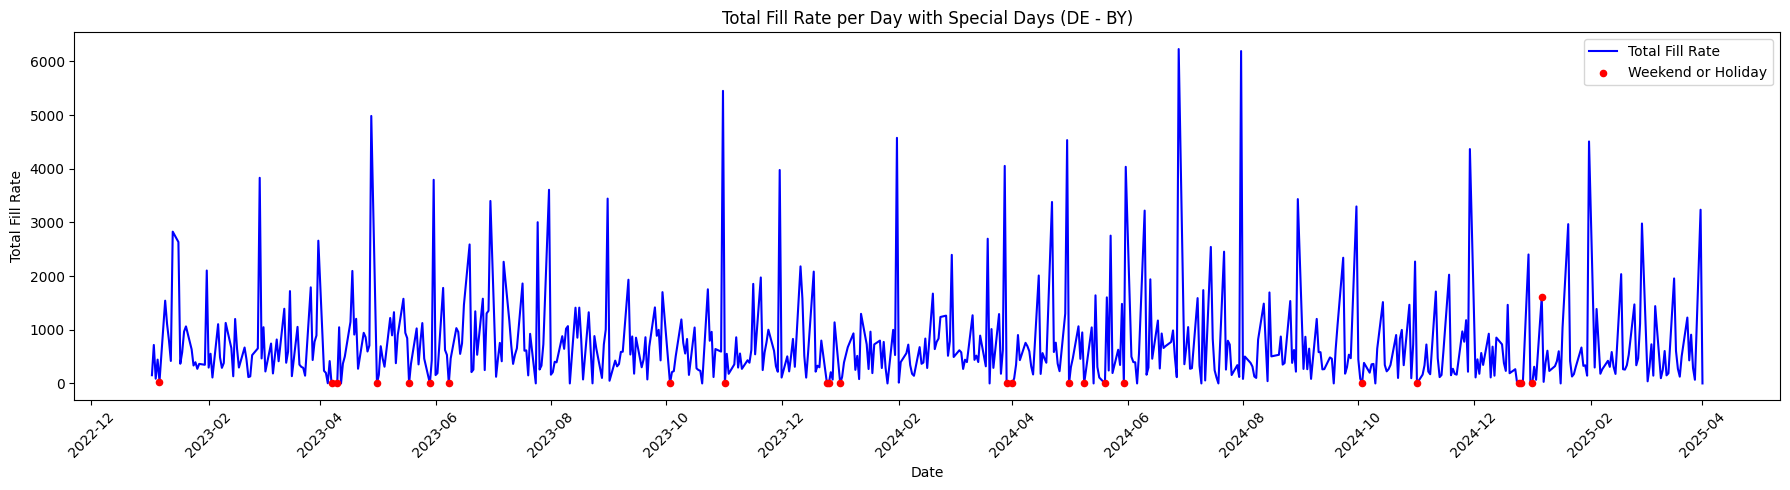

Orders on weekends: 0.0
Orders on holidays: 1652.3074576019408
Holidays in Baden-Württemberg: dict_keys([datetime.date(2024, 1, 1), datetime.date(2024, 3, 29), datetime.date(2024, 4, 1), datetime.date(2024, 5, 1), datetime.date(2024, 5, 9), datetime.date(2024, 5, 20), datetime.date(2024, 10, 3), datetime.date(2024, 12, 25), datetime.date(2024, 12, 26), datetime.date(2024, 1, 6), datetime.date(2024, 5, 30), datetime.date(2024, 11, 1), datetime.date(2025, 1, 1), datetime.date(2025, 4, 18), datetime.date(2025, 4, 21), datetime.date(2025, 5, 1), datetime.date(2025, 5, 29), datetime.date(2025, 6, 9), datetime.date(2025, 10, 3), datetime.date(2025, 12, 25), datetime.date(2025, 12, 26), datetime.date(2025, 1, 6), datetime.date(2025, 6, 19), datetime.date(2025, 11, 1), datetime.date(2023, 1, 1), datetime.date(2023, 4, 7), datetime.date(2023, 4, 10), datetime.date(2023, 5, 1), datetime.date(2023, 5, 18), datetime.date(2023, 5, 29), datetime.date(2023, 10, 3), datetime.date(2023, 12, 25), dateti

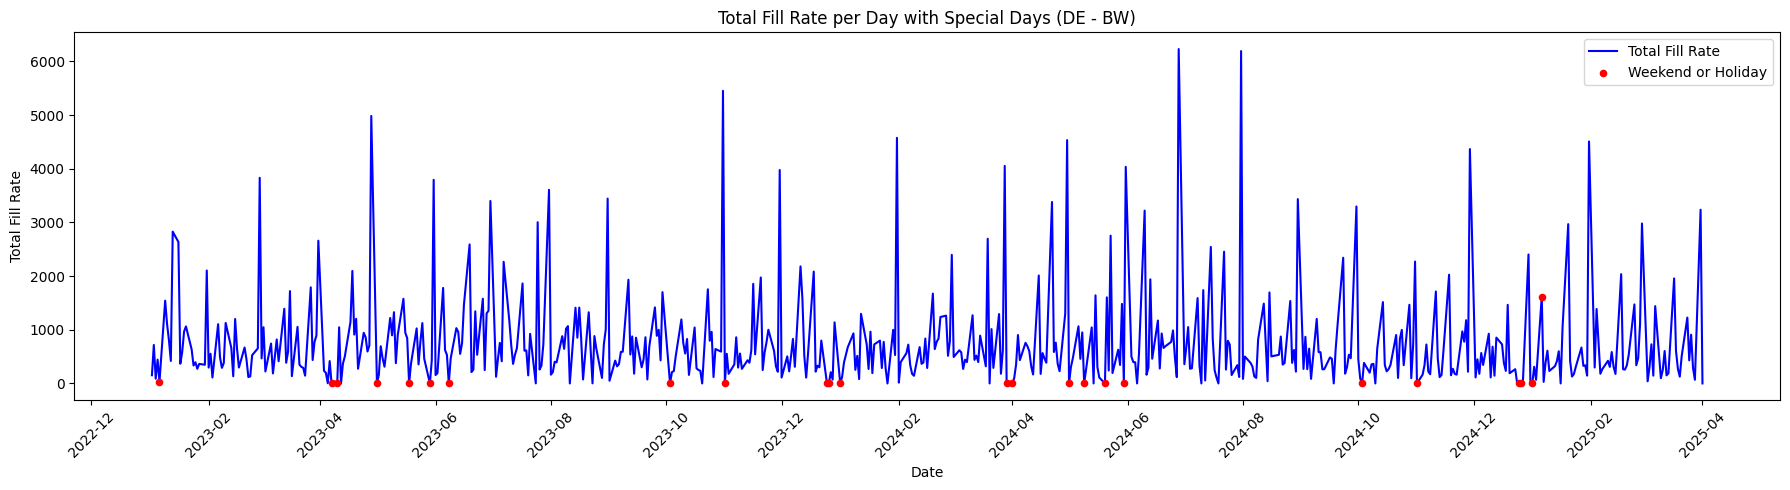

Orders on weekends: 0.0
Orders on holidays: 0.03333333333333333
Holidays in North Rhine-Westphalia: dict_keys([datetime.date(2024, 1, 1), datetime.date(2024, 3, 29), datetime.date(2024, 4, 1), datetime.date(2024, 5, 1), datetime.date(2024, 5, 9), datetime.date(2024, 5, 20), datetime.date(2024, 10, 3), datetime.date(2024, 12, 25), datetime.date(2024, 12, 26), datetime.date(2024, 5, 30), datetime.date(2024, 11, 1), datetime.date(2025, 1, 1), datetime.date(2025, 4, 18), datetime.date(2025, 4, 21), datetime.date(2025, 5, 1), datetime.date(2025, 5, 29), datetime.date(2025, 6, 9), datetime.date(2025, 10, 3), datetime.date(2025, 12, 25), datetime.date(2025, 12, 26), datetime.date(2025, 6, 19), datetime.date(2025, 11, 1), datetime.date(2023, 1, 1), datetime.date(2023, 4, 7), datetime.date(2023, 4, 10), datetime.date(2023, 5, 1), datetime.date(2023, 5, 18), datetime.date(2023, 5, 29), datetime.date(2023, 10, 3), datetime.date(2023, 12, 25), datetime.date(2023, 12, 26), datetime.date(2023, 6, 8)

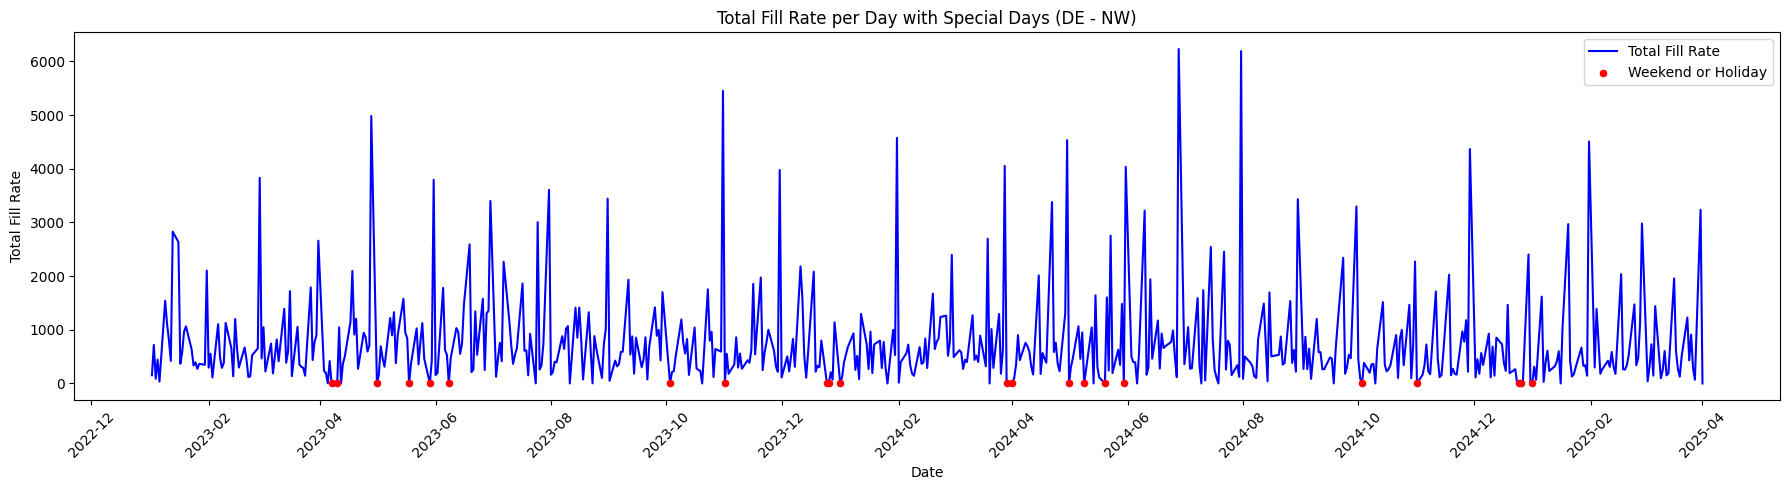

Orders on weekends: 0.0
Orders on holidays: 0.03333333333333333
Holidays in Germany: dict_keys([datetime.date(2024, 1, 1), datetime.date(2024, 3, 29), datetime.date(2024, 4, 1), datetime.date(2024, 5, 1), datetime.date(2024, 5, 9), datetime.date(2024, 5, 20), datetime.date(2024, 10, 3), datetime.date(2024, 12, 25), datetime.date(2024, 12, 26), datetime.date(2025, 1, 1), datetime.date(2025, 4, 18), datetime.date(2025, 4, 21), datetime.date(2025, 5, 1), datetime.date(2025, 5, 29), datetime.date(2025, 6, 9), datetime.date(2025, 10, 3), datetime.date(2025, 12, 25), datetime.date(2025, 12, 26), datetime.date(2023, 1, 1), datetime.date(2023, 4, 7), datetime.date(2023, 4, 10), datetime.date(2023, 5, 1), datetime.date(2023, 5, 18), datetime.date(2023, 5, 29), datetime.date(2023, 10, 3), datetime.date(2023, 12, 25), datetime.date(2023, 12, 26)])


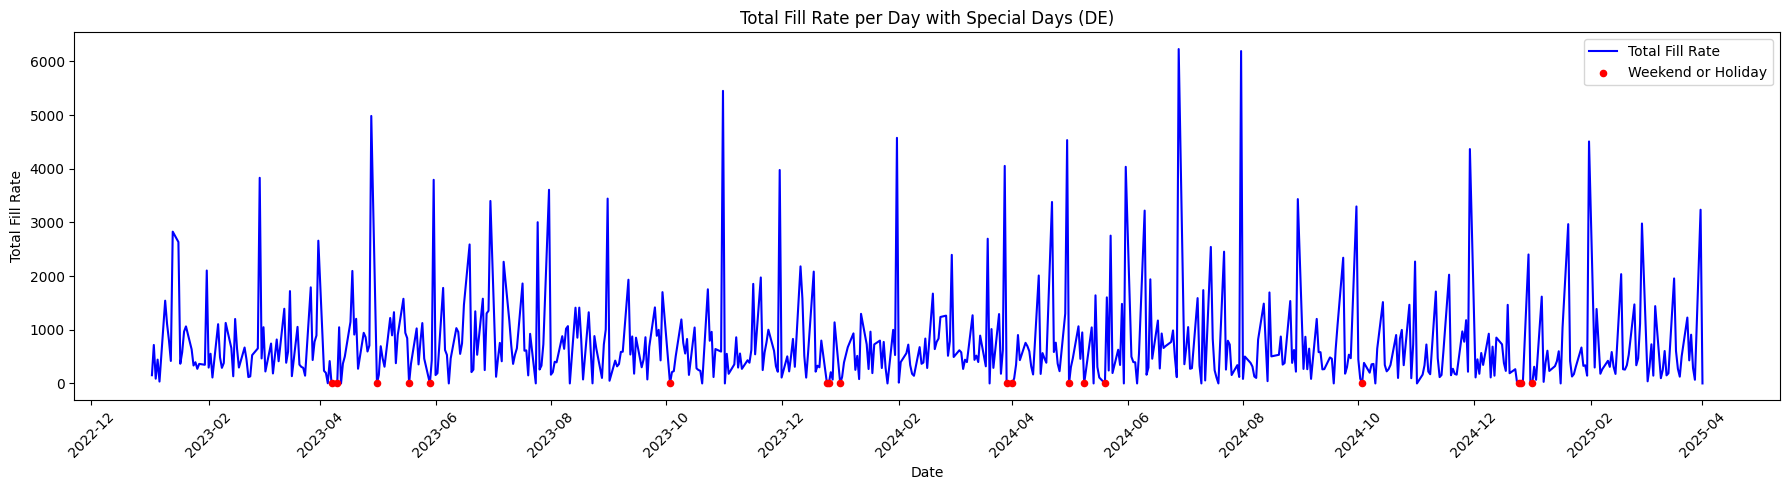

Orders on weekends: 0.0
Orders on holidays: 832.8467180556363
Holidays in Zurich: dict_keys([datetime.date(2024, 1, 1), datetime.date(2024, 5, 9), datetime.date(2024, 8, 1), datetime.date(2024, 12, 25), datetime.date(2024, 1, 2), datetime.date(2024, 3, 29), datetime.date(2024, 4, 1), datetime.date(2024, 5, 1), datetime.date(2024, 5, 20), datetime.date(2024, 12, 26), datetime.date(2025, 1, 1), datetime.date(2025, 5, 29), datetime.date(2025, 8, 1), datetime.date(2025, 12, 25), datetime.date(2025, 1, 2), datetime.date(2025, 4, 18), datetime.date(2025, 4, 21), datetime.date(2025, 5, 1), datetime.date(2025, 6, 9), datetime.date(2025, 12, 26), datetime.date(2023, 1, 1), datetime.date(2023, 5, 18), datetime.date(2023, 8, 1), datetime.date(2023, 12, 25), datetime.date(2023, 1, 2), datetime.date(2023, 4, 7), datetime.date(2023, 4, 10), datetime.date(2023, 5, 1), datetime.date(2023, 5, 29), datetime.date(2023, 12, 26)])


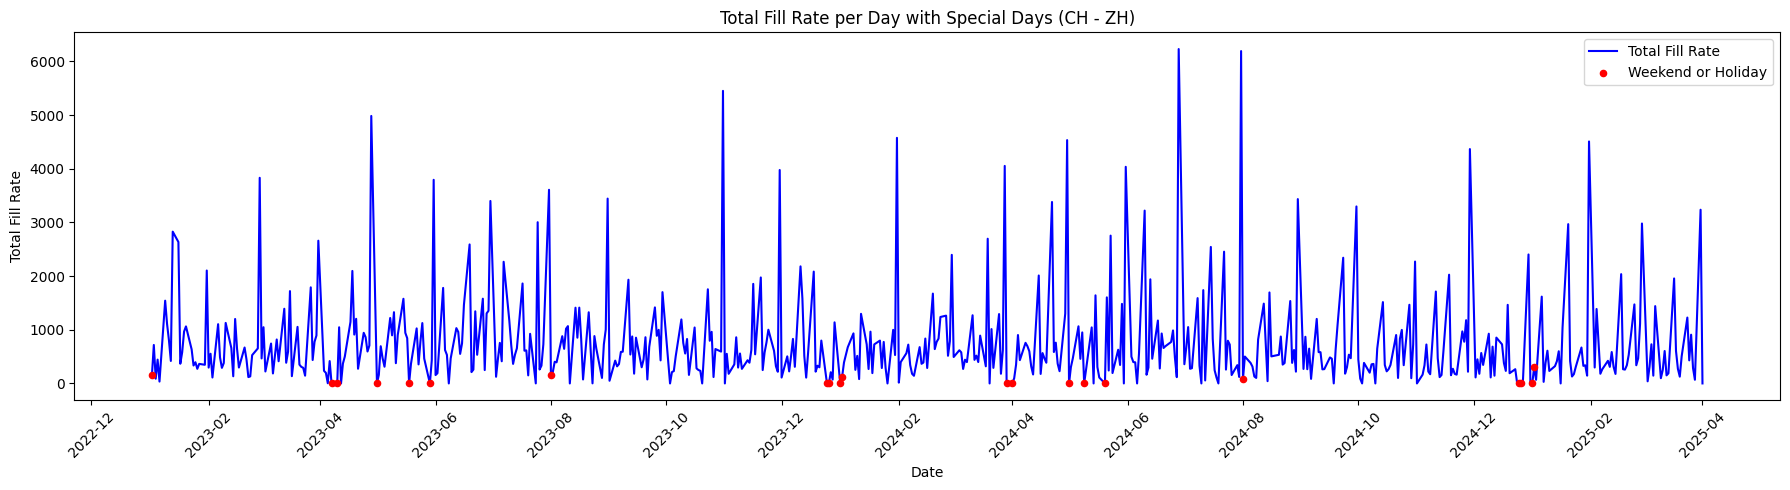

Orders on weekends: 0.0
Orders on holidays: 247.50736984248505
Holidays in St. Gallen: dict_keys([datetime.date(2024, 1, 1), datetime.date(2024, 5, 9), datetime.date(2024, 8, 1), datetime.date(2024, 12, 25), datetime.date(2024, 3, 29), datetime.date(2024, 4, 1), datetime.date(2024, 5, 20), datetime.date(2024, 11, 1), datetime.date(2024, 12, 26), datetime.date(2025, 1, 1), datetime.date(2025, 5, 29), datetime.date(2025, 8, 1), datetime.date(2025, 12, 25), datetime.date(2025, 4, 18), datetime.date(2025, 4, 21), datetime.date(2025, 6, 9), datetime.date(2025, 11, 1), datetime.date(2025, 12, 26), datetime.date(2023, 1, 1), datetime.date(2023, 5, 18), datetime.date(2023, 8, 1), datetime.date(2023, 12, 25), datetime.date(2023, 4, 7), datetime.date(2023, 4, 10), datetime.date(2023, 5, 29), datetime.date(2023, 11, 1), datetime.date(2023, 12, 26)])


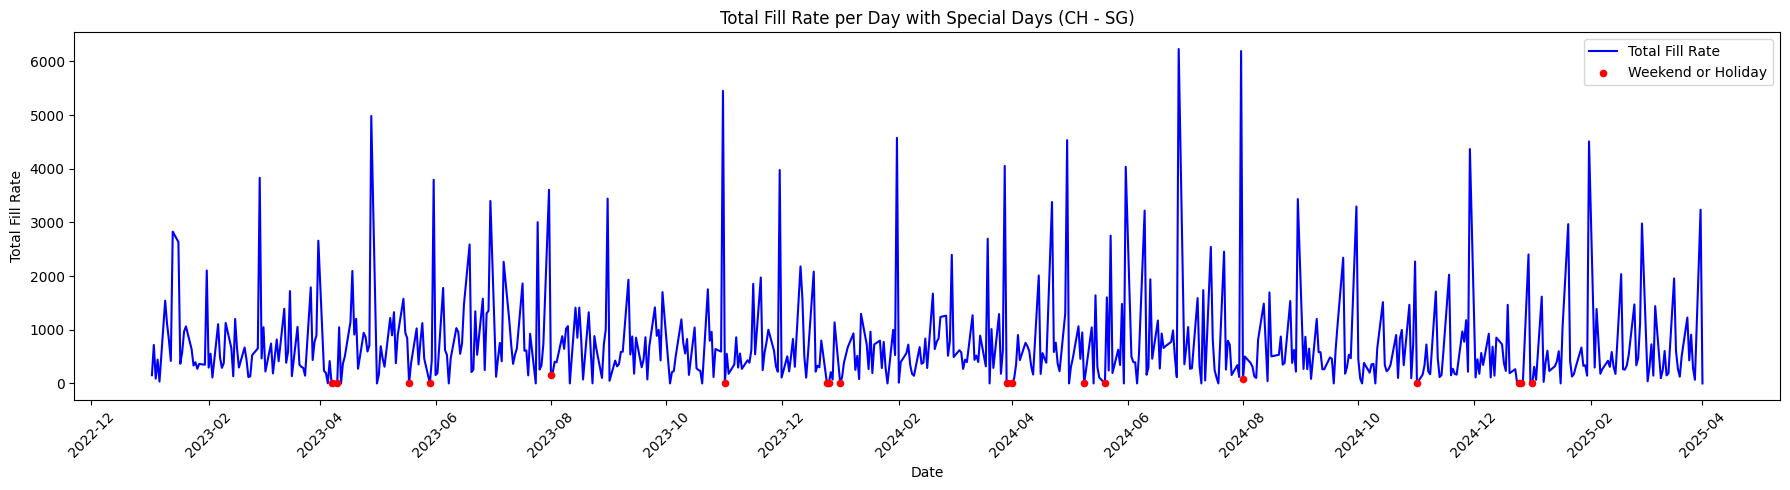

Orders on weekends: 0.0
Orders on holidays: 247.50736984248505
Holidays in Switzerland: dict_keys([datetime.date(2024, 1, 1), datetime.date(2024, 5, 9), datetime.date(2024, 8, 1), datetime.date(2024, 12, 25), datetime.date(2025, 1, 1), datetime.date(2025, 5, 29), datetime.date(2025, 8, 1), datetime.date(2025, 12, 25), datetime.date(2023, 1, 1), datetime.date(2023, 5, 18), datetime.date(2023, 8, 1), datetime.date(2023, 12, 25)])


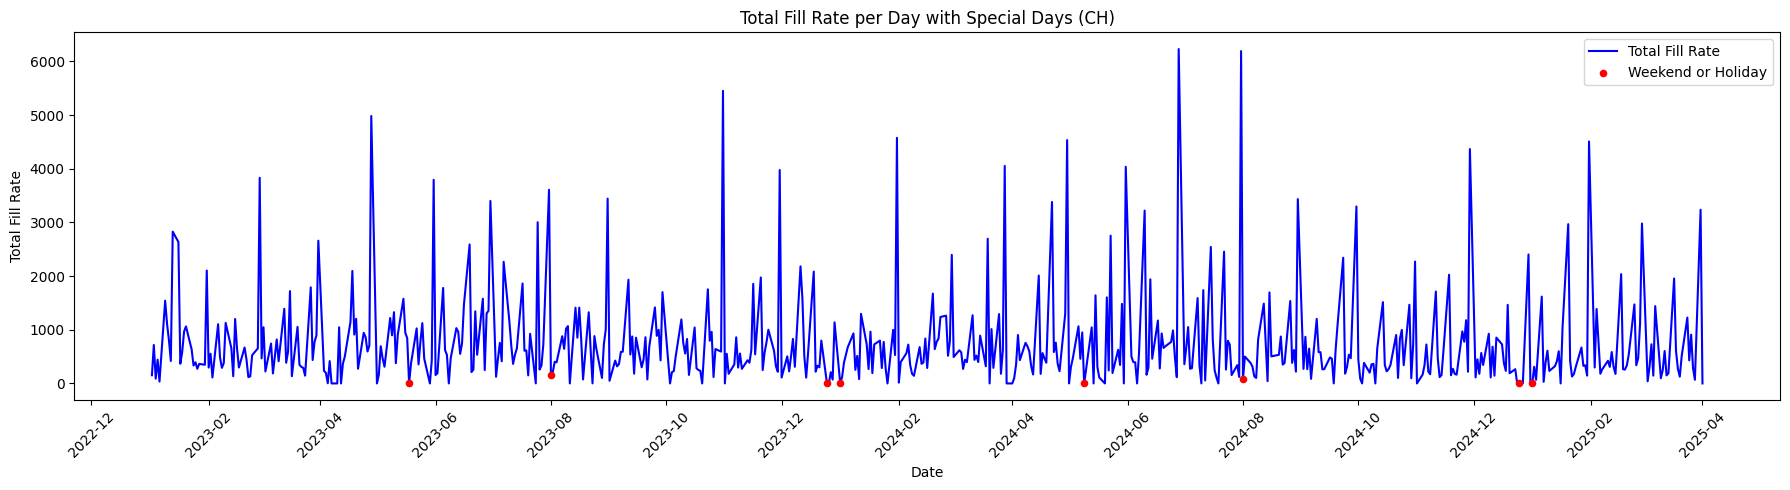

Orders on weekends: 0.0
Orders on holidays: 4629.271523742121
Holidays in Austria: dict_keys([datetime.date(2024, 1, 1), datetime.date(2024, 1, 6), datetime.date(2024, 4, 1), datetime.date(2024, 5, 1), datetime.date(2024, 5, 9), datetime.date(2024, 5, 20), datetime.date(2024, 5, 30), datetime.date(2024, 8, 15), datetime.date(2024, 10, 26), datetime.date(2024, 11, 1), datetime.date(2024, 12, 8), datetime.date(2024, 12, 25), datetime.date(2024, 12, 26), datetime.date(2025, 1, 1), datetime.date(2025, 1, 6), datetime.date(2025, 4, 21), datetime.date(2025, 5, 1), datetime.date(2025, 5, 29), datetime.date(2025, 6, 9), datetime.date(2025, 6, 19), datetime.date(2025, 8, 15), datetime.date(2025, 10, 26), datetime.date(2025, 11, 1), datetime.date(2025, 12, 8), datetime.date(2025, 12, 25), datetime.date(2025, 12, 26), datetime.date(2023, 1, 1), datetime.date(2023, 1, 6), datetime.date(2023, 4, 10), datetime.date(2023, 5, 1), datetime.date(2023, 5, 18), datetime.date(2023, 5, 29), datetime.date(20

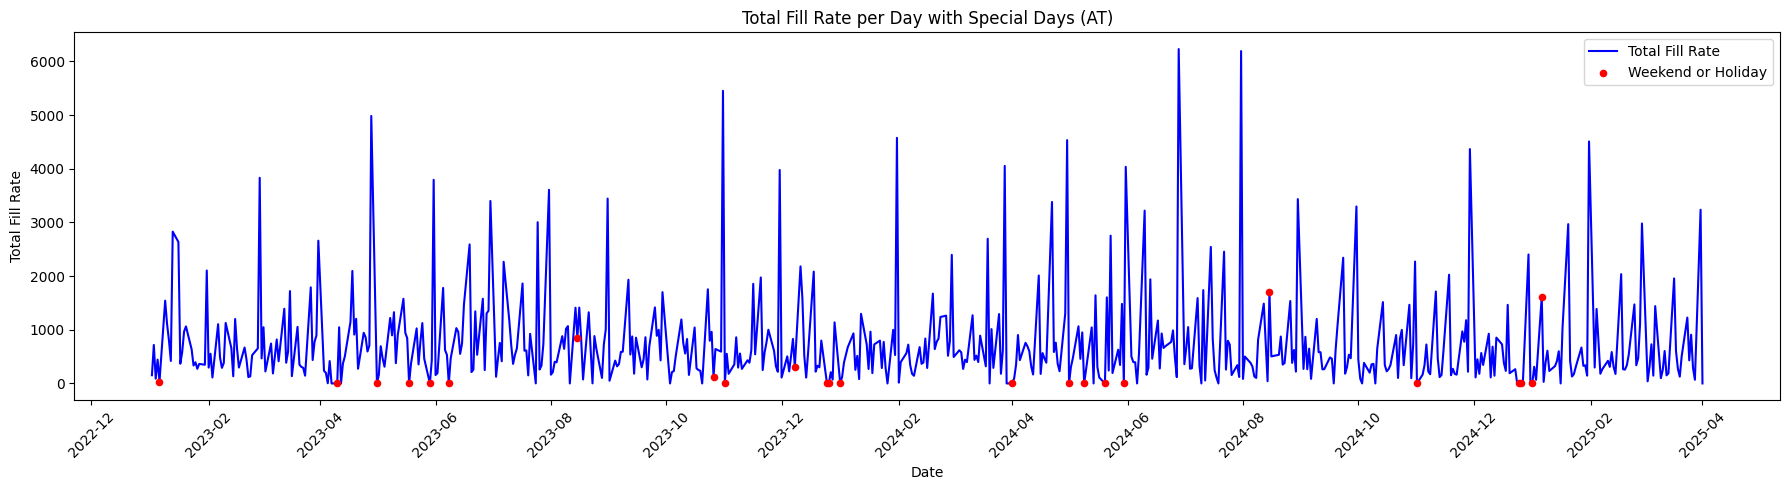

Orders on weekends: 0.0
Orders on holidays: 7083.044436348105
Holidays in France: dict_keys([datetime.date(2024, 1, 1), datetime.date(2024, 5, 1), datetime.date(2024, 5, 8), datetime.date(2024, 7, 14), datetime.date(2024, 11, 11), datetime.date(2024, 4, 1), datetime.date(2024, 5, 20), datetime.date(2024, 5, 9), datetime.date(2024, 8, 15), datetime.date(2024, 11, 1), datetime.date(2024, 12, 25), datetime.date(2025, 1, 1), datetime.date(2025, 5, 1), datetime.date(2025, 5, 8), datetime.date(2025, 7, 14), datetime.date(2025, 11, 11), datetime.date(2025, 4, 21), datetime.date(2025, 6, 9), datetime.date(2025, 5, 29), datetime.date(2025, 8, 15), datetime.date(2025, 11, 1), datetime.date(2025, 12, 25), datetime.date(2023, 1, 1), datetime.date(2023, 5, 1), datetime.date(2023, 5, 8), datetime.date(2023, 7, 14), datetime.date(2023, 11, 11), datetime.date(2023, 4, 10), datetime.date(2023, 5, 29), datetime.date(2023, 5, 18), datetime.date(2023, 8, 15), datetime.date(2023, 11, 1), datetime.date(2023

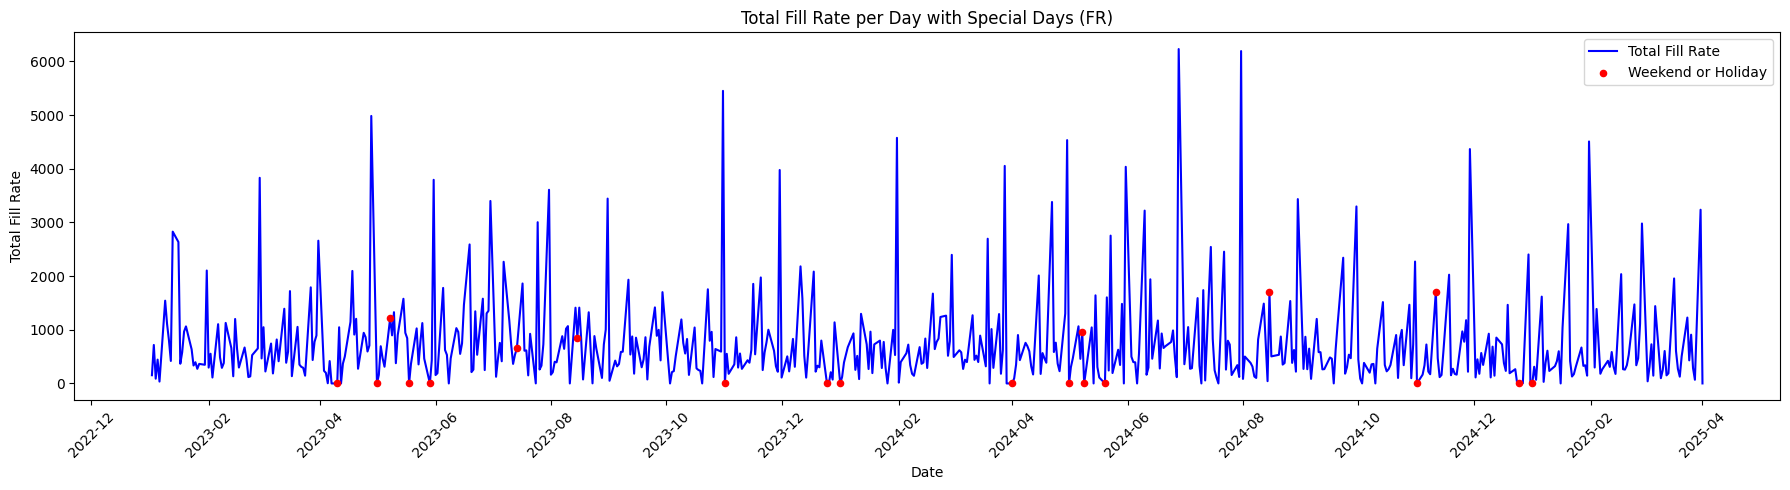

Orders on weekends: 0.0
Orders on holidays: 5929.49554858917
Holidays in Italy: dict_keys([datetime.date(2024, 1, 1), datetime.date(2024, 1, 6), datetime.date(2024, 3, 31), datetime.date(2024, 4, 1), datetime.date(2024, 4, 25), datetime.date(2024, 5, 1), datetime.date(2024, 6, 2), datetime.date(2024, 8, 15), datetime.date(2024, 11, 1), datetime.date(2024, 12, 8), datetime.date(2024, 12, 25), datetime.date(2024, 12, 26), datetime.date(2025, 1, 1), datetime.date(2025, 1, 6), datetime.date(2025, 4, 20), datetime.date(2025, 4, 21), datetime.date(2025, 4, 25), datetime.date(2025, 5, 1), datetime.date(2025, 6, 2), datetime.date(2025, 8, 15), datetime.date(2025, 11, 1), datetime.date(2025, 12, 8), datetime.date(2025, 12, 25), datetime.date(2025, 12, 26), datetime.date(2023, 1, 1), datetime.date(2023, 1, 6), datetime.date(2023, 4, 9), datetime.date(2023, 4, 10), datetime.date(2023, 4, 25), datetime.date(2023, 5, 1), datetime.date(2023, 6, 2), datetime.date(2023, 8, 15), datetime.date(2023, 11,

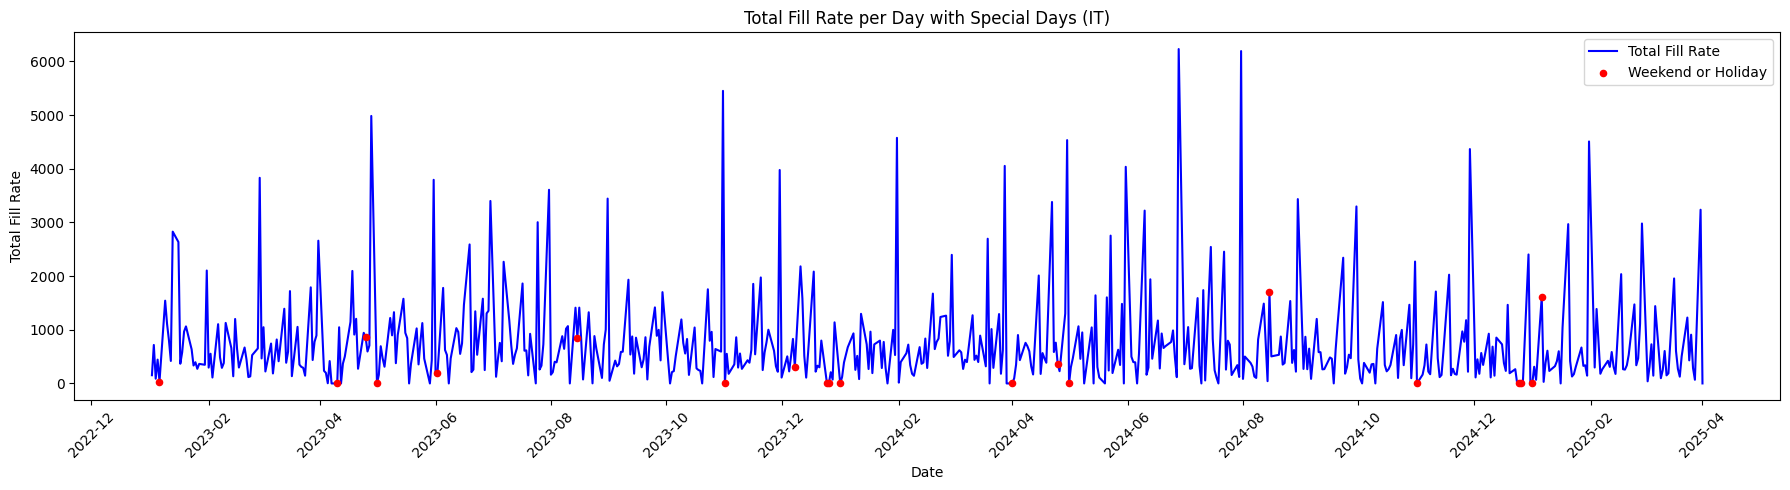

Orders on weekends: 0.0
Orders on holidays: 22115.47969083916
Holidays in USA: dict_keys([datetime.date(2024, 1, 1), datetime.date(2024, 5, 27), datetime.date(2024, 6, 19), datetime.date(2024, 7, 4), datetime.date(2024, 9, 2), datetime.date(2024, 11, 11), datetime.date(2024, 11, 28), datetime.date(2024, 12, 25), datetime.date(2024, 1, 15), datetime.date(2024, 2, 19), datetime.date(2024, 10, 14), datetime.date(2025, 1, 1), datetime.date(2025, 5, 26), datetime.date(2025, 6, 19), datetime.date(2025, 7, 4), datetime.date(2025, 9, 1), datetime.date(2025, 11, 11), datetime.date(2025, 11, 27), datetime.date(2025, 12, 25), datetime.date(2025, 1, 20), datetime.date(2025, 2, 17), datetime.date(2025, 10, 13), datetime.date(2023, 1, 1), datetime.date(2023, 1, 2), datetime.date(2023, 5, 29), datetime.date(2023, 6, 19), datetime.date(2023, 7, 4), datetime.date(2023, 9, 4), datetime.date(2023, 11, 11), datetime.date(2023, 11, 10), datetime.date(2023, 11, 23), datetime.date(2023, 12, 25), datetime.dat

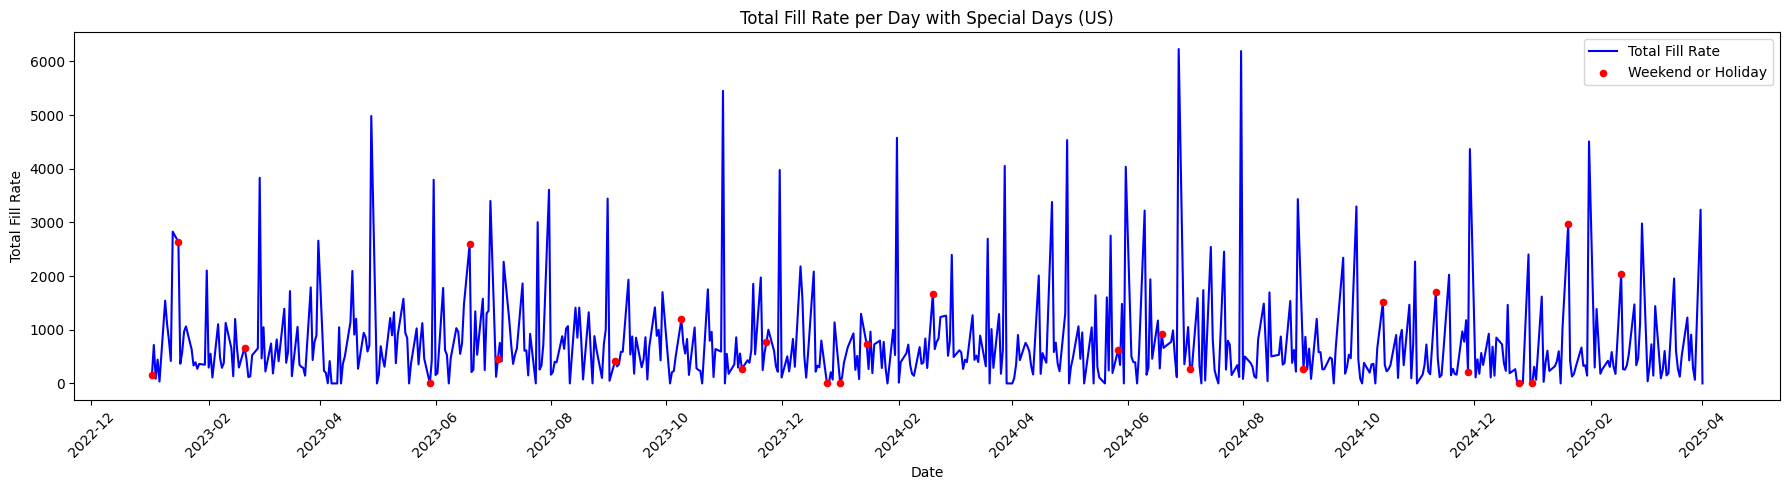

In [ ]:

# Fix: Use correct holidays API and correct column name

def plot_fill_rate_with_special_days(df, country_code, subdiv=None, ax=None):
    df_plot = df.copy().sort_values('order_date')
    # Use the correct column name for fill rate
    daily_fill = df_plot.groupby('order_date')['target_fill_rate'].sum().reset_index()

    years = daily_fill['order_date'].dt.year.unique()
    years = [int(y) for y in years]

    # Build correct holiday calendar using holidays.country_holidays
    if subdiv is not None:
        cal = holidays.country_holidays(country_code, years=years, subdiv=subdiv)
    else:
        cal = holidays.country_holidays(country_code, years=years)
    holiday_dates = pd.to_datetime(list(cal.keys()))

    daily_fill['is_weekend'] = daily_fill['order_date'].dt.weekday >= 5
    daily_fill['is_holiday'] = daily_fill['order_date'].isin(holiday_dates)
    daily_fill['special_day'] = daily_fill['is_weekend'] | daily_fill['is_holiday']

    # Optional: print some stats
    print(f"Orders on weekends: {daily_fill[daily_fill['is_weekend']]['target_fill_rate'].sum()}")
    print(f"Orders on holidays: {daily_fill[daily_fill['is_holiday']]['target_fill_rate'].sum()}")

    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(18, 5))
    ax.plot(daily_fill['order_date'], daily_fill['target_fill_rate'], label='Total Fill Rate', color='blue')
    special_days = daily_fill[daily_fill['special_day']]
    ax.scatter(special_days['order_date'], special_days['target_fill_rate'],
               color='red', label='Weekend or Holiday', s=20, zorder=5)

    ax.set_title(f"Total Fill Rate per Day with Special Days ({country_code}{' - '+subdiv if subdiv else ''})")
    ax.set_xlabel("Date")
    ax.set_ylabel("Total Fill Rate")
    ax.legend()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    return ax

def get_holiday_dates(years):
    holiday_calendars = {
        'CH_ZH': holidays.country_holidays('CH', years=years, subdiv='ZH'),      # Switzerland, Zurich
        'CH_SG': holidays.country_holidays('CH', years=years, subdiv='SG'),      # Switzerland, St. Gallen
        'CH': holidays.country_holidays('CH', years=years),                      # Switzerland, national
        'DE_BY': holidays.country_holidays('DE', years=years, subdiv='BY'),      # Germany, Bavaria
        'DE_BW': holidays.country_holidays('DE', years=years, subdiv='BW'),      # Germany, Baden-Württemberg
        'DE_NW': holidays.country_holidays('DE', years=years, subdiv='NW'),      # Germany, North Rhine-Westphalia
        'DE': holidays.country_holidays('DE', years=years),                      # Germany, national
        'AT': holidays.country_holidays('AT', years=years),                      # Austria, national
        'FR': holidays.country_holidays('FR', years=years),                      # France
        'IT': holidays.country_holidays('IT', years=years),                      # Italy
        'US': holidays.country_holidays('US', years=years),                      # USA
        'CN': holidays.country_holidays('CN', years=years),                      # China
        'JP': holidays.country_holidays('JP', years=years),                      # Japan
        'UK': holidays.country_holidays('UK', years=years)                       # United Kingdom
    }
    return holiday_calendars

# Example usage:

plot_fill_rate_with_special_days(agg_full, 'DE', subdiv='BY')  # Bavaria
print("Holidays in Bavaria:", get_holiday_dates([2023, 2024, 2025])['DE_BY'].keys())
plt.show()
plot_fill_rate_with_special_days(agg_full, 'DE', subdiv='BW')  # Baden-Württemberg
print("Holidays in Baden-Württemberg:", get_holiday_dates([2023, 2024, 2025])['DE_BW'].keys())
plt.show()
plot_fill_rate_with_special_days(agg_full, 'DE', subdiv='NW')  # North Rhine-Westphalia
print("Holidays in North Rhine-Westphalia:", get_holiday_dates([2023, 2024, 2025])['DE_NW'].keys())
plt.show()
plot_fill_rate_with_special_days(agg_full, 'DE')  # Germany national
print("Holidays in Germany:", get_holiday_dates([2023, 2024, 2025])['DE'].keys())
plt.show()
plot_fill_rate_with_special_days(agg_full, 'CH', subdiv='ZH')  # Zurich
print("Holidays in Zurich:", get_holiday_dates([2023, 2024, 2025])['CH_ZH'].keys())
plt.show()
plot_fill_rate_with_special_days(agg_full, 'CH', subdiv='SG')  # St. Gallen
print("Holidays in St. Gallen:", get_holiday_dates([2023, 2024, 2025])['CH_SG'].keys())
plt.show()
plot_fill_rate_with_special_days(agg_full, 'CH')  # Switzerland national
print("Holidays in Switzerland:", get_holiday_dates([2023, 2024, 2025])['CH'].keys())
plt.show()
plot_fill_rate_with_special_days(agg_full, 'AT')  # Austria
print("Holidays in Austria:", get_holiday_dates([2023, 2024, 2025])['AT'].keys())
plt.show()
plot_fill_rate_with_special_days(agg_full, 'FR')  # France
print("Holidays in France:", get_holiday_dates([2023, 2024, 2025])['FR'].keys())
plt.show()
plot_fill_rate_with_special_days(agg_full, 'IT')  # Italy
print("Holidays in Italy:", get_holiday_dates([2023, 2024, 2025])['IT'].keys())
plt.show()
plot_fill_rate_with_special_days(agg_full, 'US')  # USA
print("Holidays in USA:", get_holiday_dates([2023, 2024, 2025])['US'].keys())
plt.show()

Tests which calendars are a good fit

   calendar  mean_holiday_fill_rate  mean_nonholiday_fill_rate  holiday_days
5     DE_NW                0.001515                 781.763851            22
6        DE                0.001852                 776.268147            18
1     CH_SG               13.750409                 775.833219            18
2        CH               30.938421                 762.433681             8
0     CH_ZH               39.659368                 778.911241            21
3     DE_BY               68.846144                 781.606219            24
4     DE_BW               68.846144                 781.606219            24
7        AT              192.886313                 776.318539            24
13       UK              218.894042                 765.501034            14
9        IT              296.474777                 768.548701            20
8        FR              354.152222                 766.514223            20
11       CN              565.835069                 767.587230            44

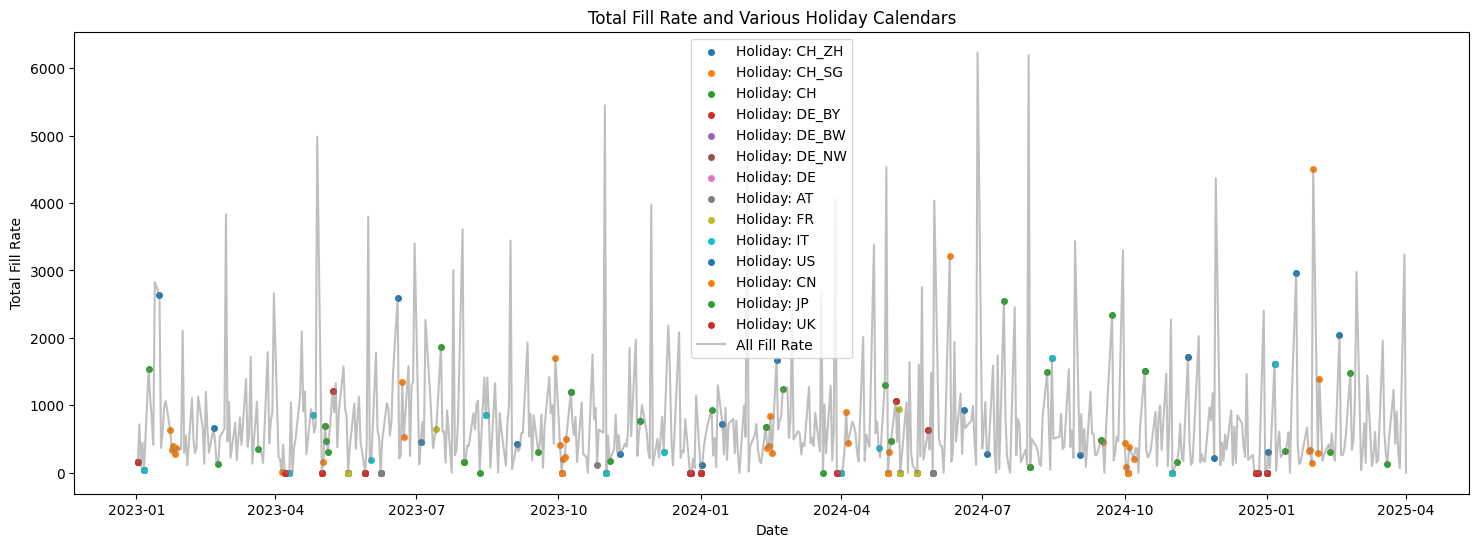

In [ ]:
def get_holiday_dates(years):
    holiday_calendars = {
        'CH_ZH': holidays.CH(years=years, subdiv='ZH'),      # Switzerland, Zurich
        'CH_SG': holidays.CH(years=years, subdiv='SG'),      # Switzerland, St. Gallen
        'CH': holidays.CH(years=years),                      # Switzerland, national
        'DE_BY': holidays.DE(years=years, subdiv='BY'),      # Germany, Bavaria
        'DE_BW': holidays.DE(years=years, subdiv='BW'),      # Germany, Baden-Württemberg
        'DE_NW': holidays.DE(years=years, subdiv='NW'),      # Germany, North Rhine-Westphalia
        'DE': holidays.DE(years=years),                      # Germany, national
        'AT': holidays.AT(years=years),                      # Austria, national
        'FR': holidays.FR(years=years),                      # France
        'IT': holidays.IT(years=years),                      # Italy
        'US': holidays.US(years=years),                      # USA
        'CN': holidays.CN(years=years),                      # China
        'JP': holidays.JP(years=years),                      # Japan
        'UK': holidays.UK(years=years)                       # United Kingdom
    }
    return holiday_calendars


def mark_holidays(daily_fill, years):
    holiday_calendars = get_holiday_dates(years)
    for code, cal in holiday_calendars.items():
        holiday_dates = pd.to_datetime(list(cal.keys()))
        daily_fill[code + '_is_holiday'] = daily_fill['order_date'].isin(holiday_dates)
    return daily_fill, list(holiday_calendars.keys())

def compare_fill_rate_on_holidays(daily_fill, calendar_codes):
    results = []
    for code in calendar_codes:
        mask = daily_fill[code + '_is_holiday']
        mean_holiday = daily_fill.loc[mask, 'target_fill_rate'].mean()
        mean_nonholiday = daily_fill.loc[~mask, 'target_fill_rate'].mean()
        count_holiday = mask.sum()
        results.append({
            'calendar': code,
            'mean_holiday_fill_rate': mean_holiday,
            'mean_nonholiday_fill_rate': mean_nonholiday,
            'holiday_days': count_holiday
        })
    return pd.DataFrame(results).sort_values('mean_holiday_fill_rate')


def plot_holiday_effects(daily_fill, calendar_codes):
    plt.figure(figsize=(18, 6))
    for code in calendar_codes:
        mask = daily_fill[code + '_is_holiday']
        plt.scatter(daily_fill.loc[mask, 'order_date'],
                    daily_fill.loc[mask, 'target_fill_rate'],
                    label=f'Holiday: {code}', s=16)
    plt.plot(daily_fill['order_date'], daily_fill['target_fill_rate'], color='grey', alpha=0.5, label='All Fill Rate')
    plt.legend()
    plt.title('Total Fill Rate and Various Holiday Calendars')
    plt.xlabel('Date')
    plt.ylabel('Total Fill Rate')
    plt.show()

# 1. Prepare your data
df_plot = df.copy().sort_values('order_date')
daily_fill = df_plot.groupby('order_date')['target_fill_rate'].sum().reset_index()
years = daily_fill['order_date'].dt.year.unique().tolist()

# 2. Mark holidays for all calendars
daily_fill, calendar_codes = mark_holidays(daily_fill, years)

# 3. Compare fill rate on holidays vs. non-holidays for each calendar
results_df = compare_fill_rate_on_holidays(daily_fill, calendar_codes)
print(results_df)

# 4. Plot
plot_holiday_effects(daily_fill, calendar_codes)

It seems like the NRW holidays are a very good fit. Let's now find out if there are still any unexplained very low fillrate days

In [ ]:
print(daily_fill.describe())

                          order_date  target_fill_rate
count                            587        587.000000
mean   2024-02-15 09:38:56.626916608        752.464410
min              2023-01-02 00:00:00          0.000000
25%              2023-07-25 12:00:00        252.165581
50%              2024-02-15 00:00:00        484.574611
75%              2024-09-07 12:00:00        894.372280
max              2025-04-01 00:00:00       6229.479141
std                              NaN        882.416402


Try to figure out which days are 0. Be careful! For some reason there are still negative fillrates

In [ ]:
# Set threshold for "very low" fill rate (adjust as needed)
min_fill = 50


# Find days with low fill rate (but more than 0) and NOT on a weekend
low_fill_not_weekend = daily_fill[(daily_fill['target_fill_rate'] <= min_fill)]

print("\nDays with very low fill rate that are NOT on a weekend:")
print(low_fill_not_weekend[['order_date', 'target_fill_rate']].sort_values('order_date'))
print(f"Total days with very low fill rate (not weekend): {len(low_fill_not_weekend)}")


Days with very low fill rate that are NOT on a weekend:
    order_date  target_fill_rate
4   2023-01-06         34.982890
67  2023-04-05          4.000000
69  2023-04-07          0.000000
70  2023-04-10          0.000000
72  2023-04-12          0.000000
85  2023-05-01          0.000000
98  2023-05-18          0.000000
105 2023-05-29          0.000000
113 2023-06-08          0.000000
145 2023-07-24          0.880820
159 2023-08-11          0.000000
167 2023-08-23          1.700641
196 2023-10-03          0.000000
209 2023-10-20          0.000000
217 2023-11-01          0.000000
255 2023-12-25          0.000000
256 2023-12-26          0.000000
260 2024-01-01          0.000000
279 2024-01-26          0.000000
283 2024-02-01         15.218876
317 2024-03-20          0.000000
324 2024-03-29          0.000000
325 2024-04-01          0.000000
347 2024-05-01          0.000000
353 2024-05-09          0.000000
356 2024-05-14          0.028571
360 2024-05-20          0.000000
368 2024-05-30     

Interesting results. Check if these days are covered by any calendar

In [ ]:
# Find columns indicating holidays
holiday_cols = [col for col in daily_fill.columns if '_is_holiday' in col]

# For each low fill day (not weekend), check if ANY holiday calendar flags it as a holiday
low_fill_not_weekend['is_holiday_any'] = low_fill_not_weekend[holiday_cols].any(axis=1)

print("\nLow fill, not weekend days -- holiday calendar coverage:")
# Print low fill, not weekend days with holiday coverage and which calendars flag as holiday
for idx, row in low_fill_not_weekend.iterrows():
    holiday_flags = [cal for cal in holiday_cols if row[cal]]
    print(f"{row['order_date'].date()} | Fill rate: {row['target_fill_rate']:.6f} | is_holiday_any: {row['is_holiday_any']} | Calendars: {', '.join(holiday_flags) if holiday_flags else 'None'}")

unexplained = low_fill_not_weekend[~low_fill_not_weekend['is_holiday_any']]

print("\nUnexplained very low fill rate days (not weekend, not any tested holiday):")
print(unexplained[['order_date', 'target_fill_rate']].sort_values('order_date'))


Low fill, not weekend days -- holiday calendar coverage:
2023-01-06 | Fill rate: 34.982890 | is_holiday_any: True | Calendars: DE_BY_is_holiday, DE_BW_is_holiday, AT_is_holiday, IT_is_holiday
2023-04-05 | Fill rate: 4.000000 | is_holiday_any: True | Calendars: CN_is_holiday
2023-04-07 | Fill rate: 0.000000 | is_holiday_any: True | Calendars: CH_ZH_is_holiday, CH_SG_is_holiday, DE_BY_is_holiday, DE_BW_is_holiday, DE_NW_is_holiday, DE_is_holiday, UK_is_holiday
2023-04-10 | Fill rate: 0.000000 | is_holiday_any: True | Calendars: CH_ZH_is_holiday, CH_SG_is_holiday, DE_BY_is_holiday, DE_BW_is_holiday, DE_NW_is_holiday, DE_is_holiday, AT_is_holiday, FR_is_holiday, IT_is_holiday
2023-04-12 | Fill rate: 0.000000 | is_holiday_any: False | Calendars: None
2023-05-01 | Fill rate: 0.000000 | is_holiday_any: True | Calendars: CH_ZH_is_holiday, DE_BY_is_holiday, DE_BW_is_holiday, DE_NW_is_holiday, DE_is_holiday, AT_is_holiday, FR_is_holiday, IT_is_holiday, CN_is_holiday, UK_is_holiday
2023-05-18 | 

C:\Users\lars-\AppData\Local\Temp\ipykernel_19412\2557742223.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  low_fill_not_weekend['is_holiday_any'] = low_fill_not_weekend[holiday_cols].any(axis=1)


Which of these are covered by NRW holidays

In [ ]:
# For each low fill day (not weekend), check if NRW holiday calendar flags it as a holiday
low_fill_not_weekend = low_fill_not_weekend.copy()
low_fill_not_weekend['is_holiday_NRW'] = low_fill_not_weekend['DE_NW_is_holiday']

# For each low fill day, list all other holidays (besides NRW) that flag as holiday
def other_holiday_flags(row):
    return [col for col in holiday_cols if col != 'DE_NW_is_holiday' and row[col]]

low_fill_not_weekend['other_holidays'] = low_fill_not_weekend.apply(other_holiday_flags, axis=1)
low_fill_not_weekend['covered_by_any_other'] = low_fill_not_weekend['other_holidays'].apply(lambda x: len(x) > 0)

# Print results
for idx, row in low_fill_not_weekend.iterrows():
    print(
        f"{row['order_date'].date()} | Fill rate: {row['target_fill_rate']:.6f} | "
        f"is_holiday_NRW: {row['is_holiday_NRW']} | "
        f"Other holidays: {', '.join(row['other_holidays']) if row['other_holidays'] else 'None'}"
    )

# Count how many are not covered by NRW
not_covered_by_nrw = low_fill_not_weekend[~low_fill_not_weekend['is_holiday_NRW']]
print(f"\nNumber of low fill days NOT covered by NRW holidays: {not_covered_by_nrw.shape[0]}")

# Are they covered by any other?
covered_by_any_other = not_covered_by_nrw['covered_by_any_other'].sum()
print(f"Of those, number covered by any other holiday: {covered_by_any_other}")
print(f"Number not covered by any holiday: {not_covered_by_nrw.shape[0] - covered_by_any_other}")

2023-01-06 | Fill rate: 34.982890 | is_holiday_NRW: False | Other holidays: DE_BY_is_holiday, DE_BW_is_holiday, AT_is_holiday, IT_is_holiday
2023-04-05 | Fill rate: 4.000000 | is_holiday_NRW: False | Other holidays: CN_is_holiday
2023-04-07 | Fill rate: 0.000000 | is_holiday_NRW: True | Other holidays: CH_ZH_is_holiday, CH_SG_is_holiday, DE_BY_is_holiday, DE_BW_is_holiday, DE_is_holiday, UK_is_holiday
2023-04-10 | Fill rate: 0.000000 | is_holiday_NRW: True | Other holidays: CH_ZH_is_holiday, CH_SG_is_holiday, DE_BY_is_holiday, DE_BW_is_holiday, DE_is_holiday, AT_is_holiday, FR_is_holiday, IT_is_holiday
2023-04-12 | Fill rate: 0.000000 | is_holiday_NRW: False | Other holidays: None
2023-05-01 | Fill rate: 0.000000 | is_holiday_NRW: True | Other holidays: CH_ZH_is_holiday, DE_BY_is_holiday, DE_BW_is_holiday, DE_is_holiday, AT_is_holiday, FR_is_holiday, IT_is_holiday, CN_is_holiday, UK_is_holiday
2023-05-18 | Fill rate: 0.000000 | is_holiday_NRW: True | Other holidays: CH_ZH_is_holiday, C

Ok, NRW holidays are definitely best

## Feature Engenieering

Try tsfresh library for feature extraction

In [ ]:
from tsfresh import extract_features

# Assume df_aggregated_daily is as you pasted above, with:
# order_date, coating_id, fill_rate, total_revenue, number_of_orders

# 1. Sort and prepare
df = df_aggregated_daily.sort_values(['coating_id', 'order_date']).reset_index(drop=True)

# 2. For tsfresh, use long format: 'id' (coating_id), 'time' (order_date), 'value' (fill_rate)
df_long = df.rename(columns={'order_date': 'time', 'coating_id': 'id', 'fill_rate': 'value'})

# 3. We'll use a rolling window of the last N days per coating_id to generate features.
WINDOW_SIZE = 14  # You can change this as desired

feature_frames = []
target_frames = []

for id_val in df_long['id'].unique():
    sub = df_long[df_long['id'] == id_val].copy()
    sub = sub.sort_values('time').reset_index(drop=True)
    # For each day, predict the fill_rate on the NEXT day
    for i in range(WINDOW_SIZE, len(sub) - 1):
        window = sub.iloc[i-WINDOW_SIZE:i]
        # tsfresh expects at least a few rows per window
        features = extract_features(
            window,
            column_id='id',
            column_sort='time',
            disable_progressbar=True
        )
        # Identify the date to predict: the *next* day
        pred_time = sub.iloc[i+1]['time']
        target_val = sub.iloc[i+1]['value']  # fill_rate to predict
        features['id'] = id_val
        features['time'] = pred_time
        feature_frames.append(features)
        target_frames.append({'id': id_val, 'time': pred_time, 'target': target_val})

# Combine into feature/target tables
features_df = pd.concat(feature_frames, ignore_index=True)
targets_df = pd.DataFrame(target_frames)
# Merge features and targets
data_for_ml = features_df.merge(targets_df, on=['id', 'time'])

print("Shape of features dataframe:", data_for_ml.shape)
print(data_for_ml.head())

# At this point, data_for_ml contains:
# - id: coating_id
# - time: the date you're predicting
# - [tsfresh features]
# - target: the fill_rate on that day (to be predicted)

# You can now split data_for_ml by time for ML (e.g., time-based train/test split), drop 'id' and 'time' if needed, and train your ML model.

KeyboardInterrupt: 

Instead to it manually

Ideas:
- use 1 day lag
- use 2 day lag
- use 7 day lag
- rolling 3 days mean fillrate (only include workdays???)
- rolling 7 days mean fillrate 
- day of week
- month
- holiday - possibly use a holiday marker , maybe also a day before or after holiday marker, maybe also days after/before last holiday as feature
- sales per group this year so far - identify demand increase
- days since last order 
- customer order count (compare it to last year/month)


Further ideas:

- integrate standard deviation/max/min over the last couple of days
- 365 day lag feature/keep in mind same weekday
- interaction features (multiplication)
- include macro data like general economic trend/external data, maybe even weather
- break it down to the individual customer/order might help - we might be able to find more patterns there
- price change/promotion flgs - any known events



In [ ]:
# Prepare years
years = df_aggregated_daily['order_date'].dt.year.unique()

# Define holidays for all regions
ch_zh_holidays = holidays.CH(years=years, subdiv='ZH')
ch_sg_holidays = holidays.CH(years=years, subdiv='SG')
de_by_holidays = holidays.DE(years=years, subdiv='BY')
de_nw_holidays = holidays.DE(years=years, subdiv='NW')

# Sort
df = df_aggregated_daily.sort_values(['coating_id', 'order_date']).reset_index(drop=True)

# Lags
for lag in [1, 2, 7]:
    df[f'fill_rate_lag_{lag}'] = df.groupby('coating_id')['fill_rate'].shift(lag)

# Rolling stats
for window in [3, 7]:
    df[f'fill_rate_roll_mean_{window}'] = df.groupby('coating_id')['fill_rate'].shift(1).rolling(window).mean().reset_index(level=0, drop=True)
    df[f'fill_rate_roll_std_{window}'] = df.groupby('coating_id')['fill_rate'].shift(1).rolling(window).std().reset_index(level=0, drop=True)
    df[f'fill_rate_roll_min_{window}'] = df.groupby('coating_id')['fill_rate'].shift(1).rolling(window).min().reset_index(level=0, drop=True)
    df[f'fill_rate_roll_max_{window}'] = df.groupby('coating_id')['fill_rate'].shift(1).rolling(window).max().reset_index(level=0, drop=True)

# Day of week, month
df['day_of_week'] = df['order_date'].dt.weekday  # Monday=0
df['month'] = df['order_date'].dt.month

# Holiday markers (and before/after markers) for all regions
regions = {
    'ch_zh': ch_zh_holidays,
    'ch_sg': ch_sg_holidays,
    'de_by': de_by_holidays,
    'de_nw': de_nw_holidays
}
for region, holiday_list in regions.items():
    df[f'is_holiday_{region}'] = df['order_date'].isin(holiday_list)
    df[f'is_holiday_before_{region}'] = df['order_date'].shift(-1).isin(holiday_list)
    df[f'is_holiday_after_{region}'] = df['order_date'].shift(1).isin(holiday_list)

# Year for cumsum
df['year'] = df['order_date'].dt.year

# Cumulative fill rate for YTD (per coating_id)
df['cum_fill_rate_ytd'] = df.groupby(['coating_id', 'year'])['fill_rate'].cumsum()

# Days since last order
df['days_since_last_order'] = df.groupby('coating_id')['order_date'].diff().dt.days

# Rolling customer order count (past 30 days)
df['customer_order_count_30d'] = (
    df.groupby('coating_id')['number_of_orders']
    .shift(1)
    .rolling(30, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

# Drop rows with NaNs (due to rolling/lags)
df_fe = df.dropna().reset_index(drop=True)

print(df_fe.head())
print(df_fe.info())


  order_date  coating_id   fill_rate  total_revenue  number_of_orders  \
0 2023-01-11           1   44.723450        4080.06                72   
1 2023-01-12           1    4.660830        2781.27               114   
2 2023-01-13           1  100.957071        2786.65                88   
3 2023-01-16           1   87.775831       12152.01               132   
4 2023-01-17           1    5.515772        1120.91                15   

   fill_rate_lag_1  fill_rate_lag_2  fill_rate_lag_7  fill_rate_roll_mean_3  \
0       104.569584        80.068295         0.610664              62.835139   
1        44.723450       104.569584        35.836608              76.453776   
2         4.660830        44.723450         9.581249              51.317955   
3       100.957071         4.660830        27.812082              50.113784   
4        87.775831       100.957071         3.867537              64.464577   

   fill_rate_roll_std_3  ...  is_holiday_de_by  is_holiday_before_de_by  \
0          

C:\Users\lars-\AppData\Local\Temp\ipykernel_17884\2275324148.py:36: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df[f'is_holiday_{region}'] = df['order_date'].isin(holiday_list)
C:\Users\lars-\AppData\Local\Temp\ipykernel_17884\2275324148.py:37: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df[f'is_holiday_before_{region}'] = df['order_date'].shift(-1).isin(holiday_list)
C:\Users\lars-\AppData\Local\Temp\ipykernel_17884\2275324148.py:38: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these 